In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Analyzing Data

In [2]:
df = pd.read_csv("AI_Student_Life_Pakistan_2026.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    int64  
 1   Age                 100 non-null    int64  
 2   Gender              100 non-null    str    
 3   Education_Level     100 non-null    str    
 4   City                100 non-null    str    
 5   AI_Tool_Used        100 non-null    str    
 6   Daily_Usage_Hours   100 non-null    float64
 7   Purpose             100 non-null    str    
 8   Impact_on_Grades    100 non-null    str    
 9   Satisfaction_Level  100 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.9 KB


In [4]:
df.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,2,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,3,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low
3,4,22,Male,University,Karachi,ChatGPT,4.2,Learning,Improved,High
4,5,16,Male,School,Multan,ChatGPT,1.8,Coding,Improved,Medium


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [7]:
df['Education_Level'].unique()

<StringArray>
['School', 'College', 'University']
Length: 3, dtype: str

In [8]:
df['City'].unique()

<StringArray>
['Lahore', 'Multan', 'Karachi', 'Islamabad', 'Faisalabad']
Length: 5, dtype: str

In [9]:
df['AI_Tool_Used'].unique()

<StringArray>
['ChatGPT', 'Copilot', 'Grammarly', 'Gemini', 'Notion AI']
Length: 5, dtype: str

In [10]:
df['Purpose'].unique()

<StringArray>
['Writing', 'Learning', 'Research', 'Coding', 'Homework']
Length: 5, dtype: str

In [11]:
df['Impact_on_Grades'].unique()

<StringArray>
['Slight Decline', 'No Change', 'Improved']
Length: 3, dtype: str

In [12]:
# Our target is 'Satisfaction_Level', so let's check it
df['Satisfaction_Level'].unique()

<StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str

## Feature Encoding

In [13]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [14]:
df.head()

,Student_ID,Age,Daily_Usage_Hours,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,City_Multan,...,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Impact_on_Grades_No Change,Impact_on_Grades_Slight Decline,Satisfaction_Level_Low,Satisfaction_Level_Medium
0,1,15,0.8,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,1,1,0
1,2,15,1.6,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
2,3,16,1.8,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
3,4,22,4.2,1,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,16,1.8,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


<Axes: >

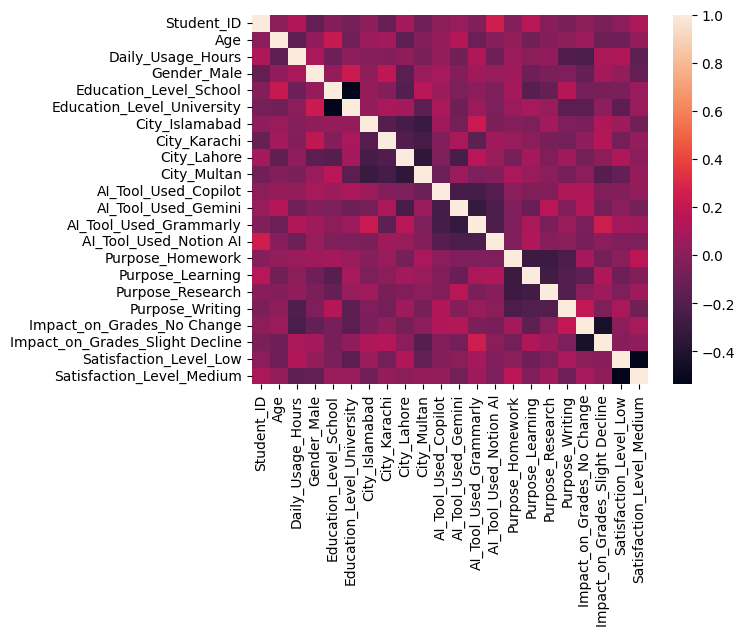

In [15]:
sns.heatmap(df.corr())

## X, y

In [16]:
df.columns

Index(['Student_ID', 'Age', 'Daily_Usage_Hours', 'Gender_Male',
       'Education_Level_School', 'Education_Level_University',
       'City_Islamabad', 'City_Karachi', 'City_Lahore', 'City_Multan',
       'AI_Tool_Used_Copilot', 'AI_Tool_Used_Gemini', 'AI_Tool_Used_Grammarly',
       'AI_Tool_Used_Notion AI', 'Purpose_Homework', 'Purpose_Learning',
       'Purpose_Research', 'Purpose_Writing', 'Impact_on_Grades_No Change',
       'Impact_on_Grades_Slight Decline', 'Satisfaction_Level_Low',
       'Satisfaction_Level_Medium'],
      dtype='str')

In [17]:
X = df.drop(columns=["Satisfaction_Level_Medium"])

In [18]:
y = df['Satisfaction_Level_Medium']

## Splitting Data

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Building model

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
model = LogisticRegression(max_iter=1000)

In [23]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

## Accuracy

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
accuracy_score(y_test, y_pred)

0.7575757575757576

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        23
           1       0.62      0.50      0.56        10

    accuracy                           0.76        33
   macro avg       0.71      0.68      0.69        33
weighted avg       0.75      0.76      0.75        33



In [29]:
confusion_matrix(y_test, y_pred)

array([[20,  3],
       [ 5,  5]])